# Random Forest: predicting where cormorants are seen

We use the merged dataset from notebook-04 (`bird_habitats_weather.parquet`). The target is binary: was at least one cormorant seen on this (location, date) row, yes or no.

**Pipeline**
1. Load the merged data.
2. Build the binary target (`seen`) from `Phalacrocorax carbo`.
3. Select features (location, habitat, weather, time).
4. Subsample to 500k rows (keeps training under ~2 min).
5. 80/20 train/test split (stratified on the target).
6. Train a `RandomForestClassifier` with `class_weight="balanced"`.
7. Evaluate with precision/recall/F1, confusion matrix, ROC-AUC.
8. Feature importance plot.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

## 1. Load the merged dataset

In [27]:
df = pd.read_parquet("bird_habitats_weather.parquet")

# In case month / day_of_year were not saved with the parquet, derive them here.
if "month" not in df.columns:
    df["month"] = df["eventDate"].dt.month
if "day_of_year" not in df.columns:
    df["day_of_year"] = df["eventDate"].dt.dayofyear

print("Shape:", df.shape)
df.head(3)

Shape: (12558756, 26)


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,1,380,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,2,380,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,3,380,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0


## 2. Build the binary target

`seen = 1` if at least one cormorant was reported on that (location, date) row, otherwise `0`. The dataset is heavily zero-inflated (~95% zeros), so a binary classifier is more meaningful than predicting raw counts.

In [28]:
df["seen"] = (df["Phalacrocorax carbo"] > 0).astype(int)

print("Class balance:")
print(df["seen"].value_counts(normalize=True).round(4))
print("\nRaw counts:")
print(df["seen"].value_counts())

Class balance:
seen
0    0.9634
1    0.0366
Name: proportion, dtype: float64

Raw counts:
seen
0    12098859
1      459897
Name: count, dtype: int64


## 3. Select features

Used:
- **Location**: `decimalLatitude`, `decimalLongitude`
- **Habitat fractions**: 8 columns
- **Main habitat**: one-hot encoded
- **Weather**: `TG, TN, TX, RH, FG, UG, SQ, Q`
- **Time**: `month`, `day_of_year`

Excluded:
- `total_observations` and `speciesgroup_observations` (these describe observer effort, not environmental conditions - including them would leak "how busy was this site today" into the prediction).
- `STN` (redundant with lat / lon).
- `eventDate` (already captured by `month` / `day_of_year`).
- Rows with missing weather (~0.17%) are dropped before training.

In [ ]:
feature_cols = [
    "decimalLatitude", "decimalLongitude",
    "agricultural", "built", "coast", "forest",
    "other", "sand/heather", "water", "wetland",
    "TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q",
    "month", "day_of_year",
]

model_df = df[feature_cols + ["main_habitat", "seen"]].dropna()
model_df = pd.get_dummies(model_df, columns=["main_habitat"], prefix="habitat")

print("Rows after dropping NaN:", len(model_df))
print("Final feature columns:", [c for c in model_df.columns if c != "seen"])

Rows after dropping NaN: 12535916
Final feature columns: ['decimalLatitude', 'decimalLongitude', 'agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland', 'TG', 'TN', 'TX', 'RH', 'FG', 'UG', 'SQ', 'Q', 'month', 'day_of_year', 'habitat_agricultural', 'habitat_built', 'habitat_coast', 'habitat_forest', 'habitat_other', 'habitat_sand/heather', 'habitat_water', 'habitat_wetland']


## 4. Subsample for speed

Training a random forest on 12.5M rows is slow. We take a stratified subsample of 500k rows (keeps the same class ratio as the original ~5% positive).

In [30]:
SAMPLE_SIZE = 500_000

pos = model_df[model_df["seen"] == 1]
neg = model_df[model_df["seen"] == 0]

n_pos = int(SAMPLE_SIZE * len(pos) / len(model_df))
n_neg = SAMPLE_SIZE - n_pos

model_df = pd.concat([
    pos.sample(n=n_pos, random_state=RANDOM_STATE),
    neg.sample(n=n_neg, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Sample size:", len(model_df))
print("Class balance in sample:")
print(model_df["seen"].value_counts(normalize=True).round(4))

Sample size: 500000
Class balance in sample:
seen
0    0.9634
1    0.0366
Name: proportion, dtype: float64


## 5. 80/20 train/test split (stratified)

Stratified split keeps the class proportions the same in both sets.

In [31]:
X = model_df.drop(columns=["seen"])
y = model_df["seen"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train shape: {X_train.shape}, positives: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test shape : {X_test.shape}, positives: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

Train shape: (400000, 28), positives: 14,640 (3.66%)
Test shape : (100000, 28), positives: 3,660 (3.66%)


## 6. Train the Random Forest

- `n_estimators=100` - 100 decision trees voting.
- `class_weight="balanced"` - penalises misclassifying the minority class more (otherwise the model would just predict "not seen" for everything and get 95% accuracy).
- `n_jobs=-1` - use all CPU cores.
- `max_depth=20` - cap tree depth to avoid overfitting and speed things up.

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)
print("Training done.")

Training done.


## 7. Evaluate the model

Predict on the held-out 20% test set and report:
- Precision / recall / F1 per class
- Confusion matrix
- ROC-AUC (probability-based, independent of decision threshold)

In [33]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["not seen", "seen"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

    not seen       0.98      0.94      0.96     96340
        seen       0.21      0.39      0.27      3660

    accuracy                           0.92    100000
   macro avg       0.59      0.67      0.61    100000
weighted avg       0.95      0.92      0.93    100000

ROC-AUC: 0.8459


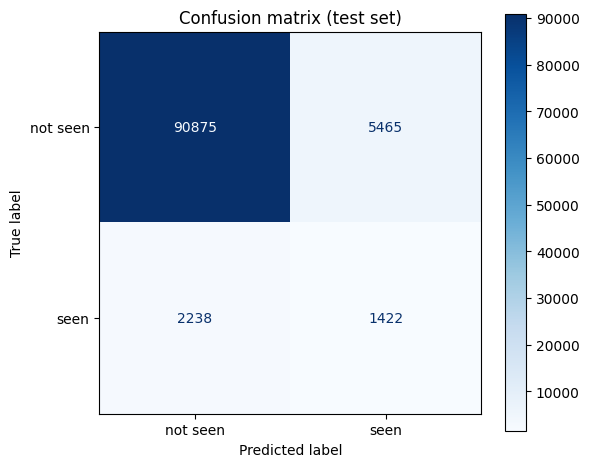

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["not seen", "seen"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

## 8. Feature importance

Which features did the forest rely on most?

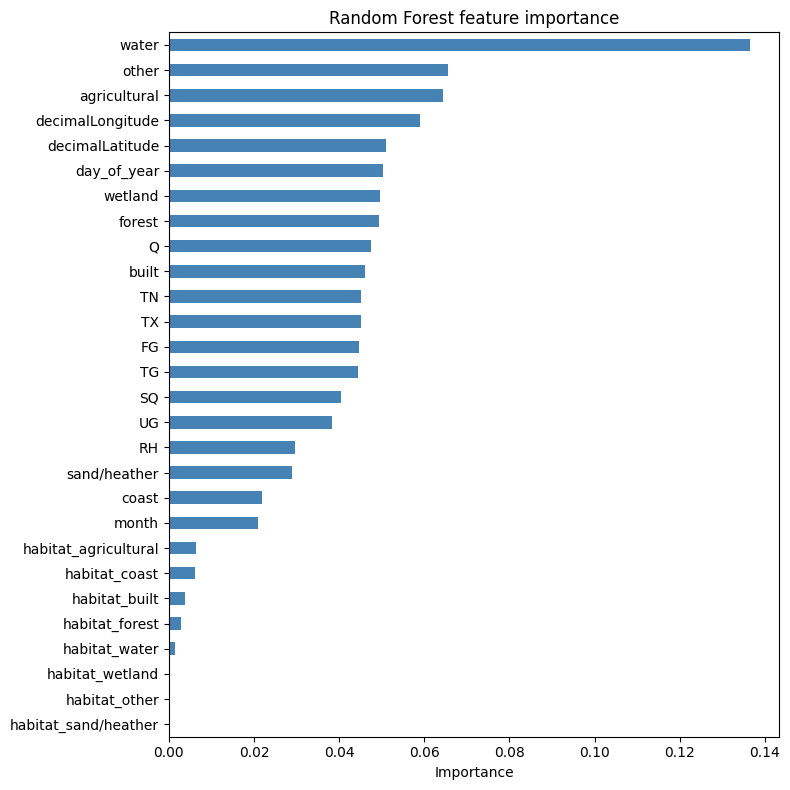

water               0.136544
other               0.065648
agricultural        0.064491
decimalLongitude    0.058933
decimalLatitude     0.051078
day_of_year         0.050303
wetland             0.049662
forest              0.049348
Q                   0.047386
built               0.046140
TN                  0.045150
TX                  0.045140
FG                  0.044681
TG                  0.044487
SQ                  0.040509
dtype: float64

In [35]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
importance.plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("Random Forest feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importance.sort_values(ascending=False).head(15)

## 9. Plain summary - how good is the model?

In [36]:
from sklearn.metrics import accuracy_score

correct = int((y_pred == y_test).sum())
wrong   = int((y_pred != y_test).sum())
total   = len(y_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"Total test predictions : {total:,}")
print(f"Got right              : {correct:,}  ({correct/total*100:.2f}%)")
print(f"Got wrong              : {wrong:,}  ({wrong/total*100:.2f}%)")
print(f"Accuracy               : {accuracy_score(y_test, y_pred):.4f}")
print()
print("Breakdown of the right / wrong predictions:")
print(f"  Correctly predicted 'seen'      (true positives)  : {tp:,}")
print(f"  Correctly predicted 'not seen'  (true negatives)  : {tn:,}")
print(f"  Wrongly predicted 'seen'        (false alarms)    : {fp:,}")
print(f"  Missed a real sighting          (false negatives) : {fn:,}")

Total test predictions : 100,000
Got right              : 92,297  (92.30%)
Got wrong              : 7,703  (7.70%)
Accuracy               : 0.9230

Breakdown of the right / wrong predictions:
  Correctly predicted 'seen'      (true positives)  : 1,422
  Correctly predicted 'not seen'  (true negatives)  : 90,875
  Wrongly predicted 'seen'        (false alarms)    : 5,465
  Missed a real sighting          (false negatives) : 2,238


## Notes / next steps

- The random 80/20 split here ignores temporal / spatial autocorrelation, so the test score is optimistic. A more honest evaluation would use a time-based split (train on 2010-2023, test on 2024-2025) or grouped CV by station / year.
- 500k subsample is enough for a first pass. For final results, retrain on a larger sample or the full data (slower).
- Hyperparameters were not tuned. Try a small grid over `n_estimators` (100-300), `max_depth` (10-30), `min_samples_leaf` (1-20).
- Try gradient boosting (`HistGradientBoostingClassifier`) for comparison - typically stronger on tabular data.